# Life Cycle Impact Assessment: 3D-Printed Biopolymer

**Project:** RAW Project — 3D-Printed Biopolymer Panels  
**Database:** `lca_database_3DPrintedBiopol`  
**Ecoinvent version:** 3.12, cut-off system model  
**Date:** 2026  

## Purpose

This notebook performs the Life Cycle Impact Assessment (LCIA) for 1 kg of 3D-printed biopolymer material (dried and baked, ready for use), using the foreground database built in `LifeCycleInventory_master.ipynb`. It covers impact assessment across all EF v3.1 categories, a process-level contribution analysis for three focal impact categories, and a one-at-a-time sensitivity analysis across all foreground exchanges.

## Structure

| Section | Content |
|---|---|
| 0 | Setup and version pinning |
| 1 | Load database and define functional unit |
| 2 | Full LCIA — all EF v3.1 categories |
| 3 | Contribution analysis |
| 4 | Sensitivity analysis |

---

## 0. Setup and version pinning

Import all required libraries, print environment versions for reproducibility, and connect to the Brightway project.

In [22]:
import bw2data as bd
import bw2io as bi
import bw2calc as bc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import importlib.metadata

# ── Version pinning ───────────────────────────────────────────────────────────
# Print environment versions so the computational context is documented
# in the notebook output.
for pkg in ["bw2data", "bw2io", "bw2calc", "numpy", "pandas", "matplotlib"]:
    print(f"  {pkg}: {importlib.metadata.version(pkg)}")
print()

# ── Connect to project ────────────────────────────────────────────────────────
bd.projects.set_current("biopol_lca")
ei = bd.Database("ecoinvent-3.12-cutoff")
print(f"  ecoinvent: {len(ei)} datasets")

  bw2data: 4.4.2
  bw2io: 0.9.6
  bw2calc: 2.0.1
  numpy: 1.26.4
  pandas: 2.2.3
  matplotlib: 3.10.1

  ecoinvent: 26533 datasets


In [23]:
# ── Safety export ─────────────────────────────────────────────────────────────
# Export the current foreground database to Excel for archival.
# This notebook does not modify the database; the export is a snapshot
# of the state at the time this notebook was run.
import os
from datetime import datetime, timezone

DB_NAME   = "lca_database_3DPrintedBiopol"
TIMESTAMP = datetime.now(timezone.utc).strftime('%Y%m%d_%H%M%S')
EXPORT_DIR = "../results/lca_export"
os.makedirs(EXPORT_DIR, exist_ok=True)

if DB_NAME in bd.databases:
    export_path = bi.export.write_lci_excel(
        DB_NAME,
        dirpath=EXPORT_DIR
    )
    # Rename the file to include the timestamp
    base, ext = os.path.splitext(export_path)
    stamped_path = f"{base}_{TIMESTAMP}{ext}"
    os.rename(export_path, stamped_path)
    print(f"Database exported to: {stamped_path}")
else:
    print(f"WARNING: database '{DB_NAME}' not found — run LifeCycleInventory_master.ipynb first.")

Database exported to: ../results/lca_export/lci-lca_database_3DPrintedBiopol_20260626_135622.xlsx


## 1. Load database and define functional unit

Load `lca_database_3DPrintedBiopol`, retrieve the reference activity (`Kiln baking`, 1 kg baked biopolymer panel), and define the three focal impact categories as named constants used throughout sections 2–4.

### Focal impact categories

Three impact categories from EF v3.1 are selected for the contribution analysis and sensitivity analysis, based on their relevance to the material system under study:

| Category | EF v3.1 identifier | Unit | Rationale |
|---|---|---|---|
| Climate change (GWP100) | `climate change` | kg CO2-eq | Baseline category for all LCA studies; directly relevant to bio-based material claims |
| Land use | `land use` | dimensionless (soil quality index) | Distinguishes agricultural ingredients (peas, cotton) from waste-derived inputs (hemp dust, bark, cellulose); expected to reveal the footprint of the binder chain |
| Eutrophication, terrestrial | `eutrophication: terrestrial` | mol N-eq | Captures nitrogen deposition from fertiliser use in pea and cotton cultivation, which are the most process-intensive agricultural ingredients in the binder chain |

All 16 EF v3.1 categories are calculated in Section 2 and presented in full. The three focal categories are used in Sections 3 and 4 for deeper process-level and sensitivity analysis.

In [24]:
# ── Load foreground database ──────────────────────────────────────────────────
db  = bd.Database(DB_NAME)
print(f"Database: {DB_NAME}")
print(f"Total activities: {len(db)}")
print()

# ── Reference activity and functional unit ────────────────────────────────────
ref = bd.get_node(database=DB_NAME, name="Kiln baking")
print(f"Reference activity:  {ref['name']}")
print(f"Functional unit:     1 kg baked biopolymer panel")
print()

# ── Focal impact categories ───────────────────────────────────────────────────
# Full method tuples confirmed against bd.methods for EF v3.1.
# Used as named constants throughout sections 2–4.
METHOD_GWP  = [m for m in bd.methods if m[0] == 'EF v3.1' and 'climate change' == m[1] and 'global warming potential (GWP100)' in m[2]][0]
METHOD_LAND = [m for m in bd.methods if m[0] == 'EF v3.1' and 'land use' == m[1]][0]
METHOD_EUTR = [m for m in bd.methods if m[0] == 'EF v3.1' and 'eutrophication: terrestrial' == m[1]][0]

FOCAL_METHODS = {
    'GWP100':                  METHOD_GWP,
    'Land use':                METHOD_LAND,
    'Eutrophication (terr.)':  METHOD_EUTR,
}

print("Focal impact categories:")
for label, method in FOCAL_METHODS.items():
    print(f"  {label:<25s} {method}")
print()

# ── All EF v3.1 methods ───────────────────────────────────────────────────────
# Used in Section 2 for the full results table and normalised heatmap.
EF_METHODS = [m for m in bd.methods if m[0] == 'EF v3.1']
print(f"Total EF v3.1 categories found: {len(EF_METHODS)}")
for method in EF_METHODS:
    print(f"  {method}")

Database: lca_database_3DPrintedBiopol
Total activities: 12

Reference activity:  Kiln baking
Functional unit:     1 kg baked biopolymer panel

Focal impact categories:
  GWP100                    ('EF v3.1', 'climate change', 'global warming potential (GWP100)')
  Land use                  ('EF v3.1', 'land use', 'soil quality index')
  Eutrophication (terr.)    ('EF v3.1', 'eutrophication: terrestrial', 'accumulated exceedance (AE)')

Total EF v3.1 categories found: 25
  ('EF v3.1', 'acidification', 'accumulated exceedance (AE)')
  ('EF v3.1', 'climate change', 'global warming potential (GWP100)')
  ('EF v3.1', 'climate change: biogenic', 'global warming potential (GWP100)')
  ('EF v3.1', 'climate change: fossil', 'global warming potential (GWP100)')
  ('EF v3.1', 'climate change: land use and land use change', 'global warming potential (GWP100)')
  ('EF v3.1', 'ecotoxicity: freshwater', 'comparative toxic unit for ecosystems (CTUe)')
  ('EF v3.1', 'ecotoxicity: freshwater, inorganic

## 2. Full LCIA — all EF v3.1 categories

Run `MultiLCA` across all EF v3.1 impact categories for the functional unit. Results are presented in two forms:

- **Absolute scores table** — category, score, unit
- **Normalised heatmap** — scores divided by EF v3.1 per-person-per-year normalisation factors

### What the normalised score means

The normalised score answers the question: **"what share of the EU's total annual impact in category X is 1 kg of this material responsible for?"**

Concretely, the normalisation factor for each category is derived as:

> total EU annual impact in category X ÷ EU population

Dividing the absolute score by this factor expresses the result as a **person-year equivalent** — a dimensionless fraction of one EU person's share of the total annual European impact in that category. The "per person" framing is a communication convention; mathematically it is simply a scaling choice that makes the normalisation factors more legible in published tables.

The value of normalisation here is **within-product comparison across categories**: without it, kg CO2-eq and soil quality index points cannot be placed on the same axis. After normalisation, all 16 categories are dimensionless and their relative magnitudes become directly comparable.

> **Important caveat:** normalisation says nothing about the *importance* or *seriousness* of each impact category relative to the others. A higher normalised score means this product contributes a larger share of EU impact in that category — it does not mean that category matters more. Assigning relative importance across categories requires a separate weighting step, which is not performed in this study.

In [25]:
# ── Run MultiLCA ──────────────────────────────────────────────────────────────
functional_units = {"1 kg 3D-printed biopolymer": {ref.id: 1}}
method_config    = {"impact_categories": EF_METHODS}
data_objs        = bd.get_multilca_data_objs(
    functional_units=functional_units,
    method_config=method_config,
)

mlca = bc.MultiLCA(
    demands      =functional_units,
    method_config=method_config,
    data_objs    =data_objs,
)
mlca.lci()
mlca.lcia()
print("MultiLCA complete.")

MultiLCA complete.


In [26]:
# ── Absolute scores table ─────────────────────────────────────────────────────
# Flatten MultiLCA scores into a clean dataframe with readable labels.

# EF v3.1 units lookup — keyed on method[1]
EF_UNITS = {
    'climate change':                               'kg CO2-eq',
    'climate change: biogenic':                     'kg CO2-eq',
    'climate change: fossil':                       'kg CO2-eq',
    'climate change: land use and land use change': 'kg CO2-eq',
    'land use':                                     'dimensionless (soil quality index)',
    'water use':                                    'm3 world-eq deprived',
    'energy resources: non-renewable':              'MJ',
    'material resources: metals/minerals':          'kg Sb-eq',
    'eutrophication: freshwater':                   'kg P-eq',
    'eutrophication: marine':                       'kg N-eq',
    'eutrophication: terrestrial':                  'mol N-eq',
    'acidification':                                'mol H+-eq',
    'ecotoxicity: freshwater':                      'CTUe',
    'human toxicity: carcinogenic':                 'CTUh',
    'human toxicity: non-carcinogenic':             'CTUh',
    'ionising radiation: human health':             'kBq U235-eq',
    'ozone depletion':                              'kg CFC-11-eq',
    'particulate matter formation':                 'disease incidences',
    'photochemical oxidant formation: human health':'kg NMVOC-eq',
}

rows = []
for (method, fu_label), score in mlca.scores.items():
    label = f"{method[1]} — {method[2]}"
    unit  = EF_UNITS.get(method[1], '—')
    rows.append({"Impact category": label, "Score": score, "Unit": unit})

df_absolute = (
    pd.DataFrame(rows)
    .sort_values("Impact category")
    .reset_index(drop=True)
)

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:.4e}".format)
print("Functional unit: 1 kg 3D-printed biopolymer panel\n")
display(df_absolute)

Functional unit: 1 kg 3D-printed biopolymer panel



,Impact category,Score,Unit
0,acidification — accumulated exceedance (AE),8.4382e-03,mol H+-eq
1,climate change — global warming potential (GWP100),1.9875e+00,kg CO2-eq
2,climate change: biogenic — global warming potential (GWP100),5.6073e-03,kg CO2-eq
3,climate change: fossil — global warming potential (GWP100),1.9745e+00,kg CO2-eq
4,climate change: land use and land use change — global warming potential (GWP...,7.3506e-03,kg CO2-eq
5,ecotoxicity: freshwater — comparative toxic unit for ecosystems (CTUe),2.0117e+01,CTUe
6,"ecotoxicity: freshwater, inorganics — comparative toxic unit for ecosystems ...",1.2569e+01,—
7,"ecotoxicity: freshwater, organics — comparative toxic unit for ecosystems (C...",7.5481e+00,—
8,energy resources: non-renewable — abiotic depletion potential (ADP): fossil ...,2.3411e+01,MJ
9,eutrophication: freshwater — fraction of nutrients reaching freshwater end c...,2.1158e-03,kg P-eq


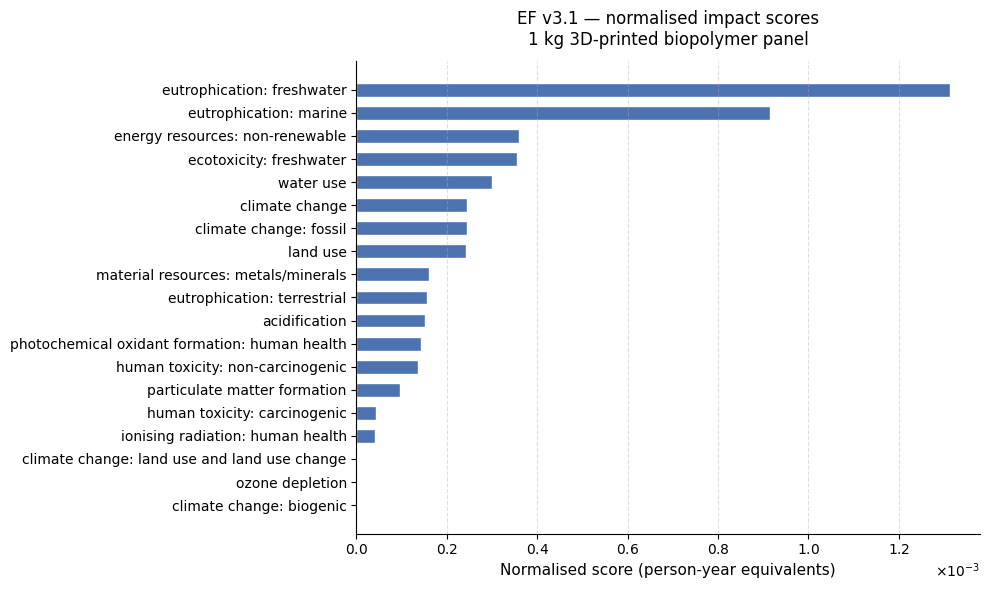

Figure saved.


In [27]:
# ── Normalised heatmap ────────────────────────────────────────────────────────
# EF v3.1 official normalisation factors (person-equivalents per year).
# Source: EC-JRC, EF 3.1 characterisation factors, Table S5.
# These convert absolute scores to dimensionless person-year fractions,
# making all categories comparable on a shared scale.

EF_NORMALISATION = {
    'climate change':                               8.1e3,
    'climate change: biogenic':                     8.1e3,
    'climate change: fossil':                       8.1e3,
    'climate change: land use and land use change': 8.1e3,
    'land use':                                     8.19e5,
    'water use':                                    1.15e4,
    'energy resources: non-renewable':              6.5e4,
    'material resources: metals/minerals':          6.36e-2,
    'eutrophication: freshwater':                   1.61,
    'eutrophication: marine':                       1.95e1,
    'eutrophication: terrestrial':                  1.77e2,
    'acidification':                                5.56e1,
    'ecotoxicity: freshwater':                      5.67e4,
    'human toxicity: carcinogenic':                 2.3e-5,
    'human toxicity: non-carcinogenic':             4.22e-4,
    'ionising radiation: human health':             4.22e3,
    'ozone depletion':                              5.36e-2,
    'particulate matter formation':                 5.95e-4,
    'photochemical oxidant formation: human health': 4.09e1,
}

# ── Compute normalised scores ─────────────────────────────────────────────────
rows_norm = []
for (method, fu_label), score in mlca.scores.items():
    norm_ref = EF_NORMALISATION.get(method[1])
    if norm_ref is None:
        continue
    normalised  = score / norm_ref
    short_label = method[1]
    rows_norm.append({"category": short_label, "normalised_score": normalised})

df_norm = (
    pd.DataFrame(rows_norm)
    .drop_duplicates(subset="category")
    .sort_values("normalised_score", ascending=False)
    .reset_index(drop=True)
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    df_norm["category"],
    df_norm["normalised_score"],
    color="#4C72B0",
    edgecolor="white",
    height=0.6,
)

ax.set_xlabel("Normalised score (person-year equivalents)", fontsize=11)
ax.set_title(
    "EF v3.1 — normalised impact scores\n1 kg 3D-printed biopolymer panel",
    fontsize=12, pad=12
)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("../results/figures/S2_normalised_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 3. Material benchmarking — 1 kg of each input material

Before examining the full product system, this section benchmarks the environmental performance of each input material in isolation: 1 kg of pea protein binder, and 1 kg of each of the six filler options. This gives context for interpreting the contribution analysis and the sensitivity analysis — a material that performs poorly here will dominate the product system in proportion to its recipe fraction.

**Functional unit:** 1 kg of each material, as produced (i.e. the output of each foreground production activity).

**Impact categories:** GWP100, land use, terrestrial eutrophication (EF v3.1).

> Note: scores reflect the full upstream chain of each material, including background ecoinvent processes (electricity, transport, chemicals). They are directly comparable across materials within each impact category.

Loaded 7 material activities.

Benchmark scores (1 kg of each material):


,GWP100,Land use,Eutrophication (terr.)
Pea protein binder,5.5239e-01,9.7326e+01,1.1368e-02
Seagrass filler,4.7319e-01,1.1033e+00,2.6484e-03
Bark flour filler,2.4917e-01,1.8751e+01,2.0312e-03
Cellulose filler,3.7994e-01,9.0976e-01,2.1809e-03
Cotton filler,1.1262e+00,9.7804e+01,9.0270e-02
Hemp dust filler,2.1417e-01,5.6575e-01,1.3499e-03
Wood flour filler,1.4169e-01,1.6423e+01,1.3264e-03


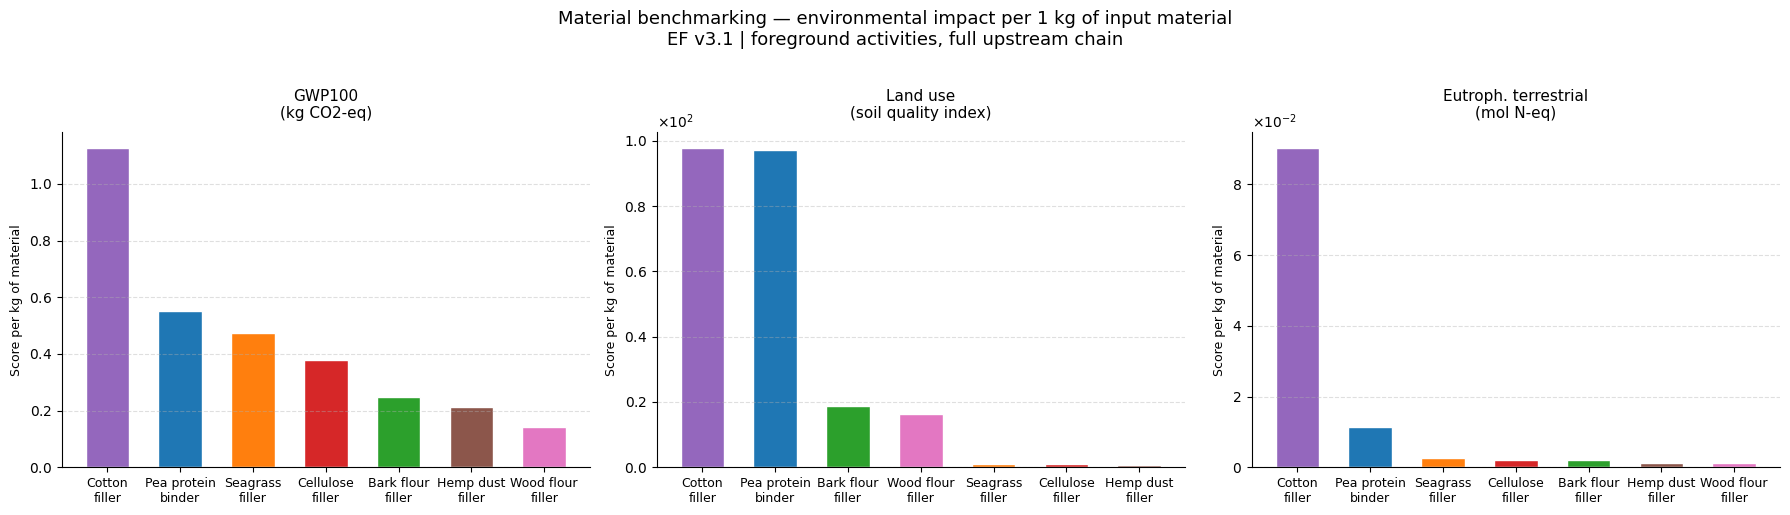

Figure saved.


In [28]:
# ── Material benchmarking — 1 kg of each input material ──────────────────────

MATERIAL_ACTIVITIES = {
    "Pea protein binder":   "pea protein binder production",
    "Seagrass filler":      "seagrass filler production",
    "Bark flour filler":    "bark flour filler production",
    "Cellulose filler":     "cellulose filler production",
    "Cotton filler":        "cotton filler production",
    "Hemp dust filler":     "hemp dust filler production",
    "Wood flour filler":    "wood flour filler production",
}

# ── Retrieve activity objects ─────────────────────────────────────────────────
material_acts = {}
for label, name in MATERIAL_ACTIVITIES.items():
    results = [a for a in db if a["name"] == name]
    if not results:
        print(f"WARNING: '{name}' not found")
    else:
        material_acts[label] = results[0]

print(f"Loaded {len(material_acts)} material activities.")

# ── Run LCA per material per focal category ───────────────────────────────────
# Each material is evaluated at 1 kg of its own output as the functional unit.
benchmarks = {label: {} for label in FOCAL_METHODS}

for mat_label, act in material_acts.items():
    for method_label, method in FOCAL_METHODS.items():
        lca = bc.LCA({act: 1}, method)
        lca.lci()
        lca.lcia()
        benchmarks[method_label][mat_label] = lca.score

df_bench = pd.DataFrame(benchmarks)
print("\nBenchmark scores (1 kg of each material):")
display(df_bench.style.format("{:.4e}"))

# ── Plot — grouped bar chart per focal category ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

SHORT_LABELS_BENCH = {
    "GWP100":                 "GWP100\n(kg CO2-eq)",
    "Land use":               "Land use\n(soil quality index)",
    "Eutrophication (terr.)": "Eutroph. terrestrial\n(mol N-eq)",
}

# Consistent colour per material
MAT_COLORS = {
    name: plt.cm.tab10.colors[i % 10]
    for i, name in enumerate(MATERIAL_ACTIVITIES.keys())
}

for ax, (method_label, method) in zip(axes, FOCAL_METHODS.items()):
    scores = df_bench[method_label].sort_values(ascending=False)
    colors = [MAT_COLORS[name] for name in scores.index]

    bars = ax.bar(
        range(len(scores)),
        scores.values,
        color=colors,
        edgecolor="white",
        width=0.6,
    )

    ax.set_xticks(range(len(scores)))
    ax.set_xticklabels(
        [n.replace(" filler", "\nfiller").replace(" binder", "\nbinder")
         for n in scores.index],
        fontsize=9,
        ha="center",
    )
    ax.set_title(SHORT_LABELS_BENCH[method_label], fontsize=11, pad=10)
    ax.set_ylabel("Score per kg of material", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle(
    "Material benchmarking — environmental impact per 1 kg of input material\n"
    "EF v3.1 | foreground activities, full upstream chain",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig("../results/figures/S3_material_benchmarking.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 4. Contribution analysis

Process-level contribution analysis using `bw2analyzer.utils.recursive_calculation_to_object`, visualised as interactive Sankey diagrams (one per focal impact category).

### Recipe

The contribution analysis is run on a randomly generated recipe, subject to the following constraints:

- Binder fraction: between 70% and 100% of total mix
- Fillers: 0, 1, or 2 fillers drawn randomly from the six available filler materials (seagrass, bark flour, cellulose, cotton, hemp dust, wood flour)
- If 2 fillers are used, the split between them is random
- All fractions sum to 1.0

The recipe is generated fresh each time this section is run. The `mix preparation` activity in the database is updated to reflect the generated recipe before the LCA is run, and restored to Recipe 1 defaults afterwards. Re-run the recipe generation cell to explore a different recipe.

> **Note:** Recipe 1 (the reference case from the Gitsouli protocol, DTU/CITA) uses a fixed composition: 80.1% pea protein binder and 19.9% hemp dust filler. The contribution analysis below reflects the randomly generated recipe, not Recipe 1. Recipe 1 values are restored at the end of this section.

In [29]:
import random

# ── Available fillers ─────────────────────────────────────────────────────────
FILLER_NAMES = [
    "seagrass filler production",
    "bark flour filler production",
    "cellulose filler production",
    "cotton filler production",
    "hemp dust filler production",
    "wood flour filler production",
]

# ── Generate random recipe ────────────────────────────────────────────────────
random.seed()  # fresh seed each run; set to an integer for reproducibility

# Binder fraction: between 0.70 and 1.00
binder_fraction = round(random.uniform(0.70, 1.00), 4)
filler_fraction = round(1.0 - binder_fraction, 4)

# Number of fillers: 0, 1, or 2
n_fillers = random.choice([0, 1, 2])

# If binder_fraction == 1.0, force 0 fillers
if filler_fraction == 0.0:
    n_fillers = 0

# Select fillers and split
selected_fillers = random.sample(FILLER_NAMES, k=n_fillers)

if n_fillers == 0:
    filler_splits = {}
elif n_fillers == 1:
    filler_splits = {selected_fillers[0]: filler_fraction}
else:
    # Random split between two fillers
    split = round(random.uniform(0.1, 0.9), 4)
    filler_splits = {
        selected_fillers[0]: round(filler_fraction * split, 4),
        selected_fillers[1]: round(filler_fraction * (1 - split), 4),
    }

# ── Print recipe summary ──────────────────────────────────────────────────────
print("Generated recipe:")
print(f"  Pea protein binder:  {binder_fraction:.4f} kg/kg mix  ({binder_fraction*100:.1f}%)")
for name, frac in filler_splits.items():
    short = name.replace(" production", "")
    print(f"  {short:<25s}  {frac:.4f} kg/kg mix  ({frac*100:.1f}%)")
if not filler_splits:
    print("  (no fillers)")
print(f"  Total:               {binder_fraction + sum(filler_splits.values()):.4f}")

Generated recipe:
  Pea protein binder:  0.8676 kg/kg mix  (86.8%)
  cotton filler              0.1324 kg/kg mix  (13.2%)
  Total:               1.0000


In [30]:
# ── Retrieve mix preparation activity ────────────────────────────────────────
mix_act = bd.get_node(database=DB_NAME, name="mix preparation")

# ── Save original exchange amounts ───────────────────────────────────────────
originals = {}
for exc in mix_act.exchanges():
    if exc["type"] == "technosphere":
        originals[exc.input["name"]] = exc["amount"]

print("Original exchange amounts saved.")

# ── Update exchange amounts to generated recipe ───────────────────────────────
binder_act = bd.get_node(database=DB_NAME, name="pea protein binder production")

for exc in mix_act.exchanges():
    if exc["type"] != "technosphere":
        continue
    input_name = exc.input["name"]

    if input_name == "pea protein binder production":
        exc["amount"] = binder_fraction
        exc.save()
    elif input_name in filler_splits:
        exc["amount"] = filler_splits[input_name]
        exc.save()
    elif input_name in [n for n in FILLER_NAMES]:
        # zero out fillers not in this recipe
        exc["amount"] = 0.0
        exc.save()

print("Database updated with generated recipe.")

# ── Run contribution analysis and Sankey ──────────────────────────────────────
CUTOFF_NAMES = {
    'market for electricity, medium voltage',
    'market for electricity, high voltage',
    'electricity voltage transformation from high to medium voltage',
    'market for transport, freight, lorry, unspecified',
    'market for industrial machine, heavy, unspecified',
}

ca_dict = {}
for label, method in FOCAL_METHODS.items():
    print(f"Computing contribution analysis: {label}...")
    ca = bwa.utils.recursive_calculation_to_object(
        ref,
        method,
        amount=1,
        max_level=5,
    )
    ca_dict[label] = pd.DataFrame(ca)
    print(f"  → {len(ca_dict[label])} nodes")

for label, method in FOCAL_METHODS.items():
    ca = ca_dict[label].copy()

    cutoff_labels = set(ca.loc[ca["name"].isin(CUTOFF_NAMES), "label"])
    ca_filtered = ca[~ca["parent"].isin(cutoff_labels)].copy()

    labels_list  = ca_filtered["label"].tolist()
    label_to_idx = {l: i for i, l in enumerate(labels_list)}

    unit = {
        "GWP100":                 "kg CO₂-eq",
        "Land use":               "soil quality index",
        "Eutrophication (terr.)": "mol N-eq",
    }[label]

    recipe_summary = f"binder {binder_fraction*100:.0f}%"
    for name, frac in filler_splits.items():
        recipe_summary += f" | {name.replace(' production','').replace(' filler','').strip()} {frac*100:.0f}%"

    display_names = [
        short_name(row["name"]) + f"<br>{row['score']:.4e} {unit}"
        for _, row in ca_filtered.iterrows()
    ]

    sources, targets, values, link_labels = [], [], [], []

    for _, row in ca_filtered.iterrows():
        if row["parent"] is None or row["parent"] not in label_to_idx:
            continue
        src = label_to_idx[row["label"]]
        tgt = label_to_idx[row["parent"]]
        sources.append(src)
        targets.append(tgt)
        values.append(abs(row["score"]))
        link_labels.append(
            f"{short_name(row['name'], 25)} → "
            f"{ca_filtered.loc[ca_filtered.label == row['parent'], 'name'].values[0][:25]}<br>"
            f"{row['score']:.4e} {unit} ({row['fraction']*100:.1f}%)"
        )

    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(
            pad=20,
            thickness=20,
            line=dict(color="grey", width=0.5),
            label=display_names,
            color="#4C72B0",
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            label=link_labels,
            color="rgba(150,150,150,0.25)",
        ),
    ))

    fig.update_layout(
        title=dict(
            text=f"Contribution analysis — {label}<br>"
                 f"<sup>EF v3.1 | {unit} | 1 kg 3D-printed biopolymer | "
                 f"recipe: {recipe_summary}</sup>",
            font_size=14,
        ),
        font_size=11,
        height=600,
    )

    fig.show()
    safe_label = label.replace(' ', '_').replace('(', '').replace(')', '').replace('.', '')
    fig.write_html(f"../results/figures/S3_sankey_{safe_label}.html")
    print(f"Saved: S3_sankey_{safe_label}.html")

# ── Restore original exchange amounts ─────────────────────────────────────────
for exc in mix_act.exchanges():
    if exc["type"] == "technosphere" and exc.input["name"] in originals:
        exc["amount"] = originals[exc.input["name"]]
        exc.save()

print("\nDatabase restored to Recipe 1 defaults.")

Original exchange amounts saved.
Database updated with generated recipe.
Computing contribution analysis: GWP100...
  → 24 nodes
Computing contribution analysis: Land use...
  → 9 nodes
Computing contribution analysis: Eutrophication (terr.)...
  → 20 nodes


Saved: S3_sankey_GWP100.html


Saved: S3_sankey_Land_use.html


Saved: S3_sankey_Eutrophication_terr.html

Database restored to Recipe 1 defaults.


--- 

## 5. Sensitivity analysis

Two complementary sensitivity analyses are performed to understand which parameters and design choices most influence the environmental impact of the biopolymer.

### 5.1 Parameter sensitivity — equal-share recipe

A one-at-a-time (OAT) sensitivity analysis across all technosphere exchanges in the foreground database. To ensure all materials appear in the analysis, a hypothetical equal-share recipe is used as the baseline: 50% pea protein binder and 50% fillers split equally across all six filler materials (~8.33% each). This recipe is not physically intended for production — it is a diagnostic tool to identify which process parameters matter most regardless of recipe choice.

Each exchange amount is varied ±20% while all others are held at their baseline values. Results are presented as tornado charts (one per focal impact category), ranked by absolute swing.

> **Note:** The equal-share recipe is used only for this sensitivity analysis. The `mix preparation` activity is updated before the analysis and restored to Recipe 1 defaults afterwards.

### 5.2 Recipe sensitivity — filler choice

A scenario analysis comparing the environmental impact of seven recipe configurations: one binder-only baseline (100% pea protein binder, 0% filler) and six single-filler recipes (70% pea protein binder + 30% of each filler option). Results are presented as a grouped bar chart across the three focal impact categories, directly informing filler selection decisions.

In [31]:
# ── Equal-share recipe parameters ─────────────────────────────────────────────
BINDER_FRACTION_EQ  = 0.50
FILLER_FRACTION_EQ  = 0.50
N_FILLERS           = 6
FILLER_FRACTION_EACH = round(FILLER_FRACTION_EQ / N_FILLERS, 6)  # ~0.083333 each

print("Equal-share recipe:")
print(f"  Pea protein binder:  {BINDER_FRACTION_EQ:.4f} kg/kg mix  ({BINDER_FRACTION_EQ*100:.1f}%)")
for name in FILLER_NAMES:
    print(f"  {name.replace(' production',''):<25s}  {FILLER_FRACTION_EACH:.6f} kg/kg mix  ({FILLER_FRACTION_EACH*100:.2f}%)")
print(f"  Total: {BINDER_FRACTION_EQ + FILLER_FRACTION_EQ:.4f}")

# ── Save Recipe 1 original amounts ────────────────────────────────────────────
mix_act = bd.get_node(database=DB_NAME, name="mix preparation")

originals_eq = {}
for exc in mix_act.exchanges():
    if exc["type"] == "technosphere":
        originals_eq[exc.input["name"]] = exc["amount"]

print("\nOriginal Recipe 1 amounts saved.")

# ── Apply equal-share recipe to database ──────────────────────────────────────
for exc in mix_act.exchanges():
    if exc["type"] != "technosphere":
        continue
    input_name = exc.input["name"]
    if input_name == "pea protein binder production":
        exc["amount"] = BINDER_FRACTION_EQ
        exc.save()
    elif input_name in FILLER_NAMES:
        exc["amount"] = FILLER_FRACTION_EACH
        exc.save()

print("Equal-share recipe applied to database.")

# ── Verify ────────────────────────────────────────────────────────────────────
print("\nVerification — mix preparation exchanges:")
for exc in mix_act.exchanges():
    if exc["type"] == "technosphere":
        print(f"  {exc.input['name']:<45s}  {exc['amount']:.6f}")

Equal-share recipe:
  Pea protein binder:  0.5000 kg/kg mix  (50.0%)
  seagrass filler            0.083333 kg/kg mix  (8.33%)
  bark flour filler          0.083333 kg/kg mix  (8.33%)
  cellulose filler           0.083333 kg/kg mix  (8.33%)
  cotton filler              0.083333 kg/kg mix  (8.33%)
  hemp dust filler           0.083333 kg/kg mix  (8.33%)
  wood flour filler          0.083333 kg/kg mix  (8.33%)
  Total: 1.0000

Original Recipe 1 amounts saved.
Equal-share recipe applied to database.

Verification — mix preparation exchanges:
  pea protein binder production                  0.500000
  hemp dust filler production                    0.083333
  bark flour filler production                   0.083333
  cellulose filler production                    0.083333
  cotton filler production                       0.083333
  seagrass filler production                     0.083333
  wood flour filler production                   0.083333
  market for electricity, medium voltage         0

In [32]:
# ── Collect all foreground technosphere exchanges ─────────────────────────────
# Build a flat list of all (activity, exchange) pairs in the foreground database,
# excluding production exchanges and zero-amount exchanges in the background.

foreground_exchanges = []

for act in db:
    for exc in act.exchanges():
        if exc["type"] != "technosphere":
            continue
        if exc["amount"] == 0:
            continue
        foreground_exchanges.append({
            "activity":     act["name"],
            "input":        exc.input["name"],
            "baseline":     exc["amount"],
            "exc_object":   exc,
            "label":        f"{act['name']} → {exc.input['name']}",
        })

print(f"Total foreground exchanges to vary: {len(foreground_exchanges)}")

# ── Compute baseline scores ───────────────────────────────────────────────────
baseline_scores = {}
for label, method in FOCAL_METHODS.items():
    lca = bc.LCA({ref: 1}, method)
    lca.lci()
    lca.lcia()
    baseline_scores[label] = lca.score
    print(f"Baseline {label}: {lca.score:.4e}")

# ── OAT sweep ─────────────────────────────────────────────────────────────────
DELTA = 0.20  # ±20%

results = []  # list of dicts: label, method_label, score_low, score_high

print(f"\nRunning OAT sweep across {len(foreground_exchanges)} exchanges × {len(FOCAL_METHODS)} methods...")

for i, exc_info in enumerate(foreground_exchanges):
    exc        = exc_info["exc_object"]
    baseline   = exc_info["baseline"]
    row        = {"label": exc_info["label"]}

    for method_label, method in FOCAL_METHODS.items():
        scores = []
        for direction in [-1, +1]:
            # Apply perturbation
            exc["amount"] = baseline * (1 + direction * DELTA)
            exc.save()

            # Run LCA
            lca = bc.LCA({ref: 1}, method)
            lca.lci()
            lca.lcia()
            scores.append(lca.score)

            # Restore immediately
            exc["amount"] = baseline
            exc.save()

        row[f"{method_label}_low"]  = scores[0]
        row[f"{method_label}_high"] = scores[1]

    results.append(row)

    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(foreground_exchanges)} done...")

print("OAT sweep complete.")
df_oat = pd.DataFrame(results)

Total foreground exchanges to vary: 56
Baseline GWP100: 2.0037e+00
Baseline Land use: 1.5219e+02
Baseline Eutrophication (terr.): 3.9134e-02

Running OAT sweep across 56 exchanges × 3 methods...
  10/56 done...
  20/56 done...
  30/56 done...
  40/56 done...
  50/56 done...
OAT sweep complete.


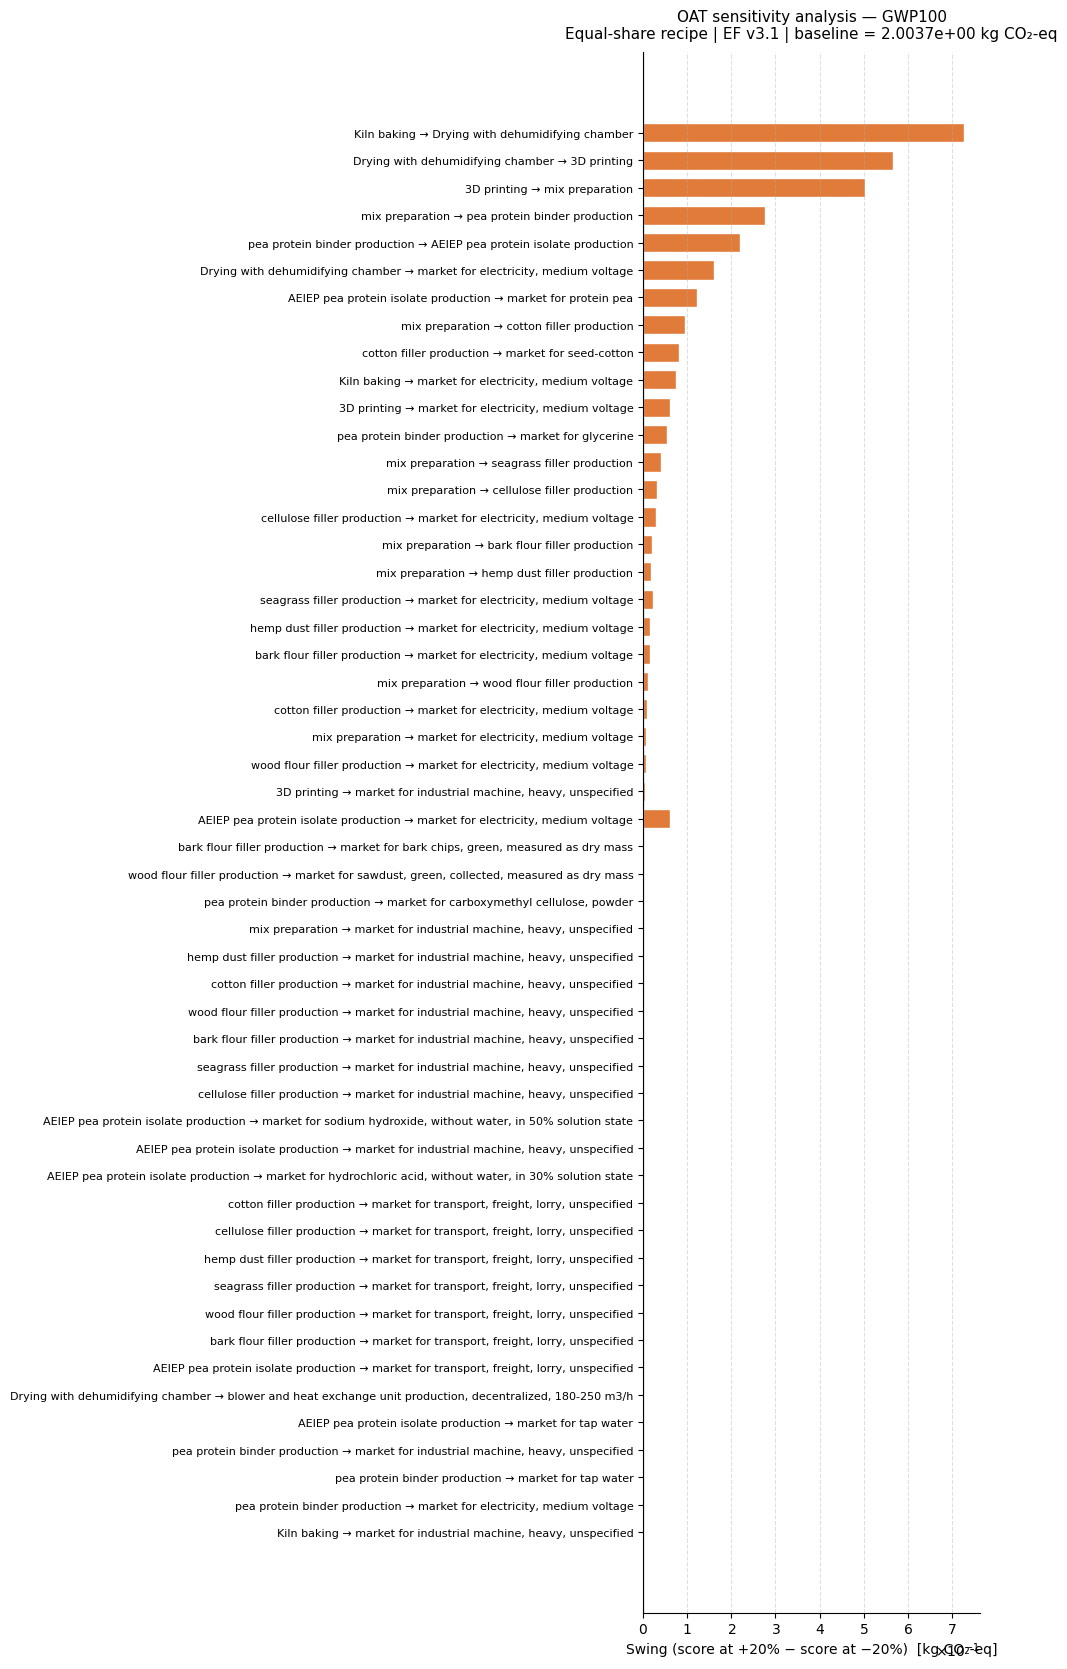

Saved: S5_tornado_GWP100.png


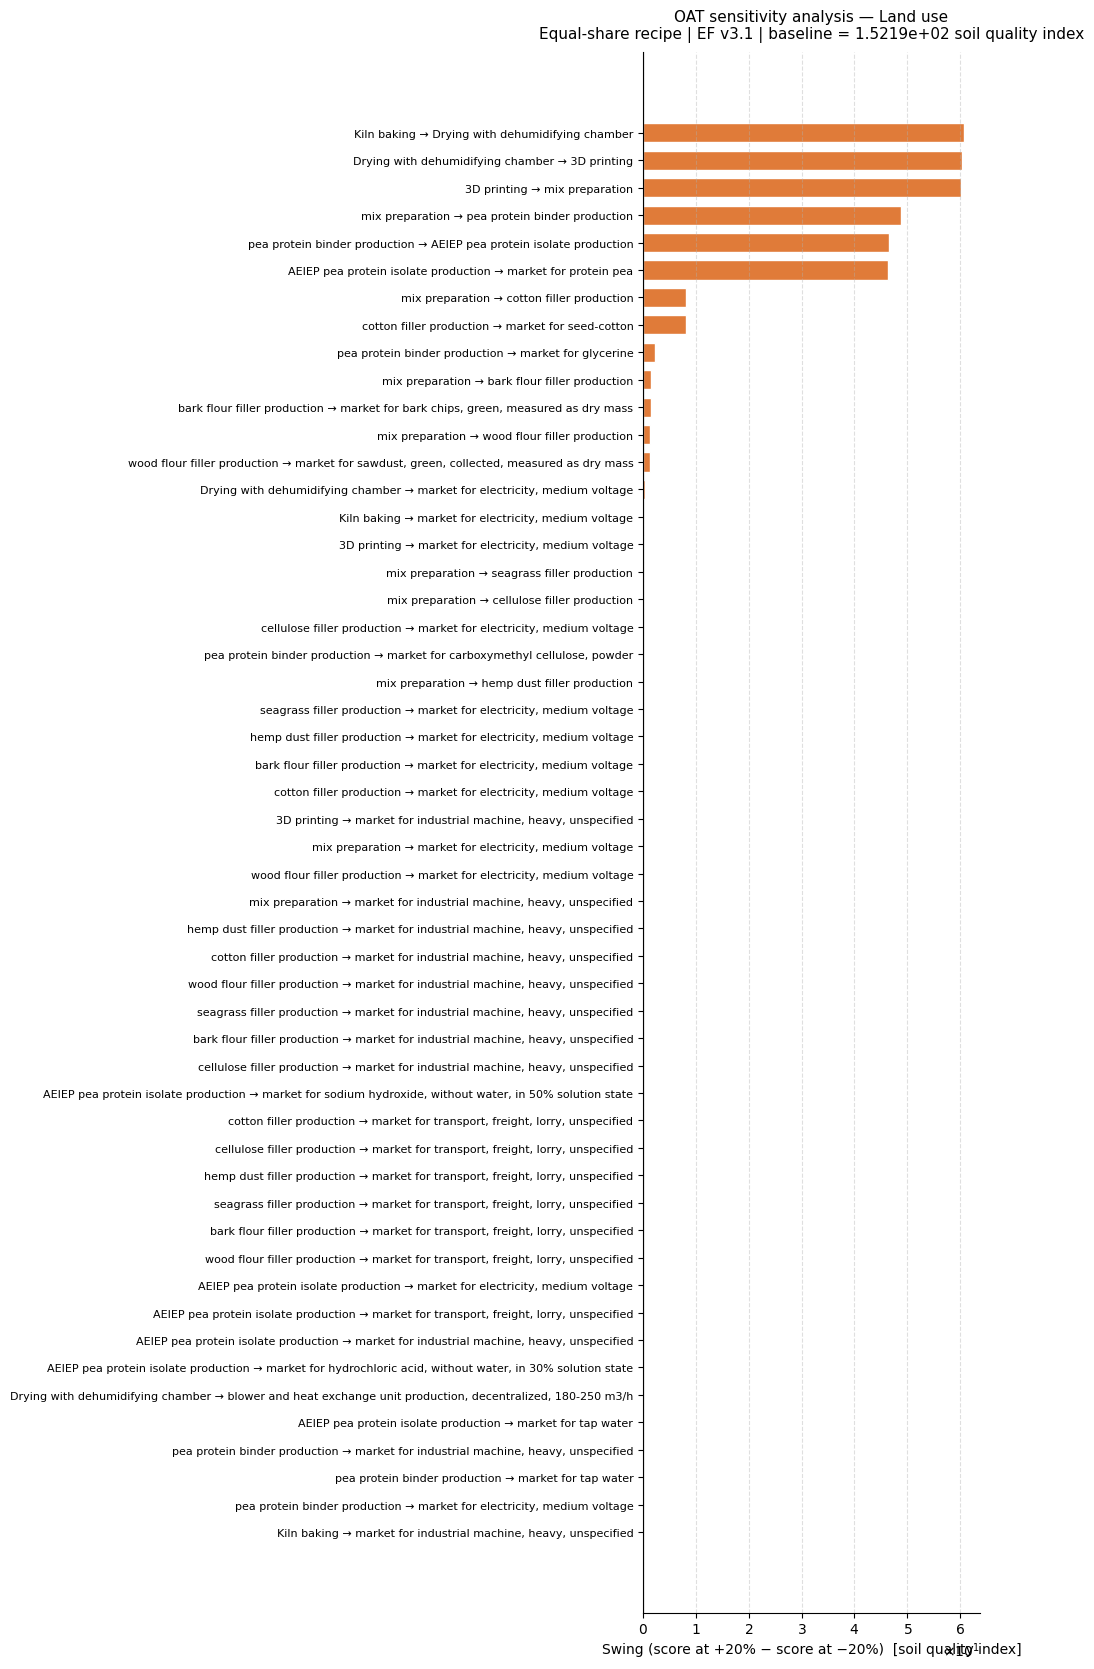

Saved: S5_tornado_Land_use.png


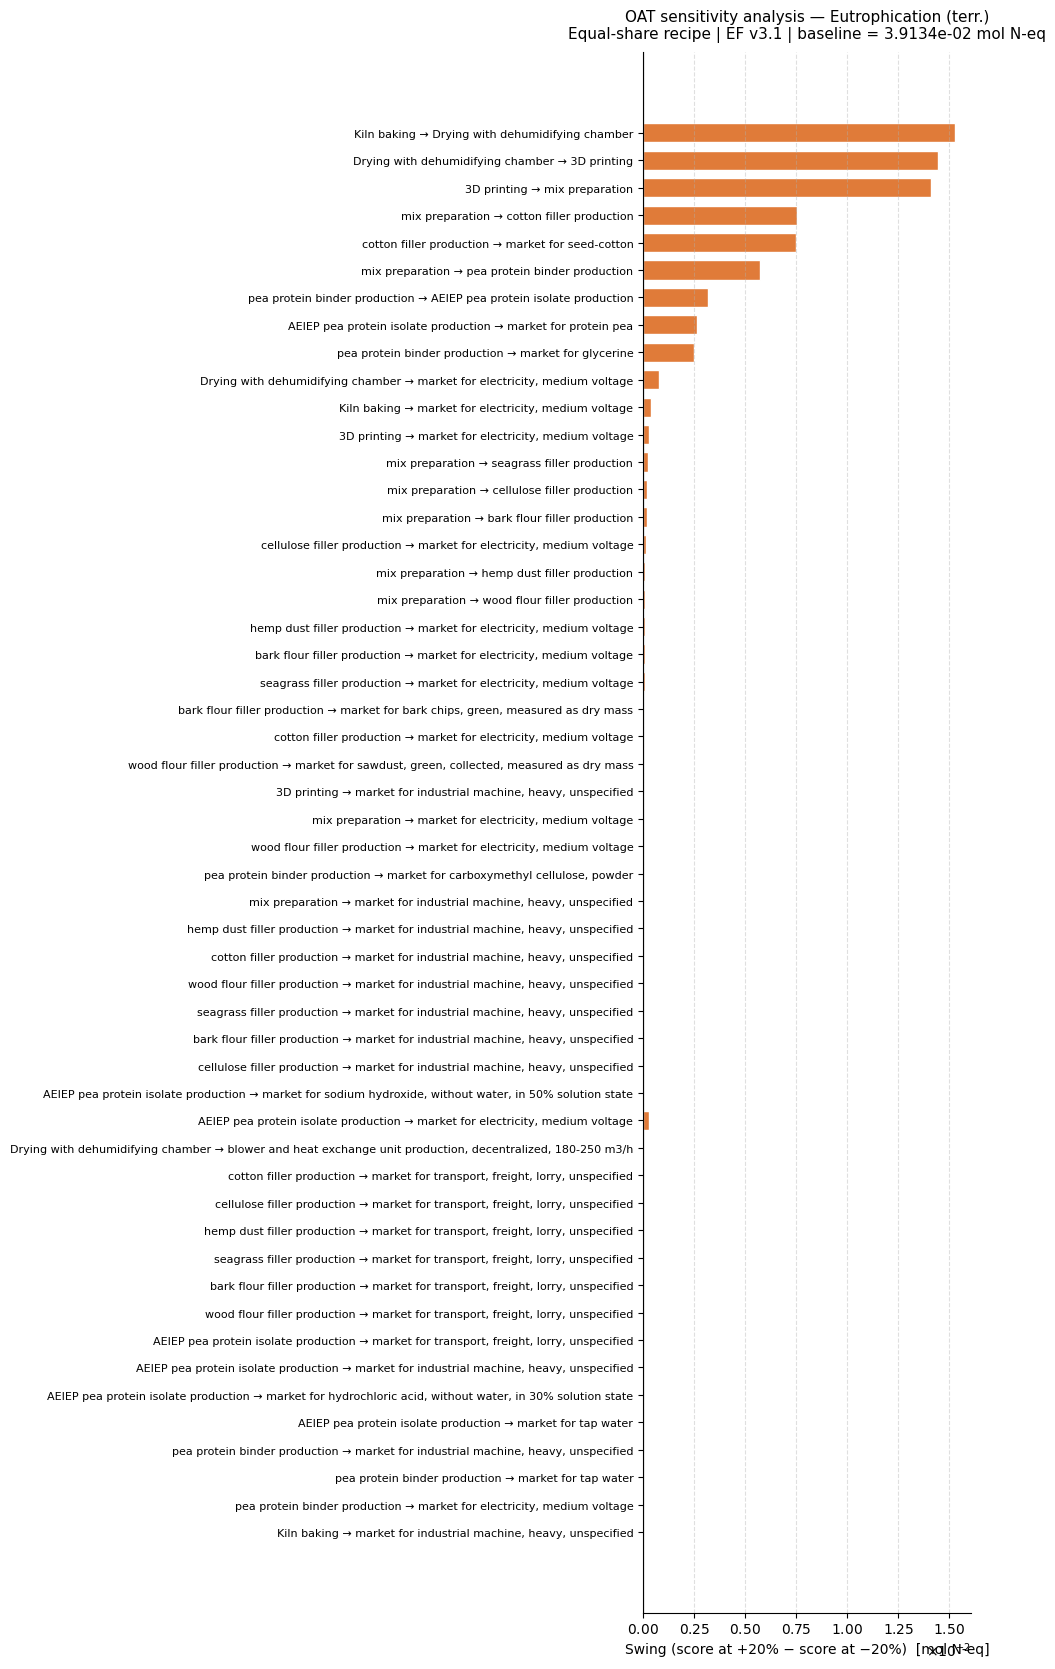

Saved: S5_tornado_Eutrophication_terr.png


In [33]:
# ── Tornado charts — one per focal category ───────────────────────────────────
os.makedirs("../results/figures", exist_ok=True)

for method_label in FOCAL_METHODS:
    baseline = baseline_scores[method_label]

    # Compute swing: score_high - score_low (positive = higher impact at +20%)
    df_oat[f"{method_label}_swing"] = (
        df_oat[f"{method_label}_high"] - df_oat[f"{method_label}_low"]
    )
    df_oat[f"{method_label}_abs_swing"] = df_oat[f"{method_label}_swing"].abs()

    # Sort by absolute swing descending
    df_sorted = df_oat.sort_values(f"{method_label}_abs_swing", ascending=True)

    # Colours: positive swing = orange (increasing +20% raises impact),
    #          negative swing = blue (increasing +20% lowers impact, e.g. avoided burden)
    colors = [
        "#E07B39" if s >= 0 else "#4C72B0"
        for s in df_sorted[f"{method_label}_swing"]
    ]

    unit = {
        "GWP100":                 "kg CO₂-eq",
        "Land use":               "soil quality index",
        "Eutrophication (terr.)": "mol N-eq",
    }[method_label]

    fig, ax = plt.subplots(figsize=(10, max(6, len(df_sorted) * 0.3)))

    ax.barh(
        df_sorted["label"],
        df_sorted[f"{method_label}_swing"],
        color=colors,
        edgecolor="white",
        height=0.7,
    )

    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(f"Swing (score at +20% − score at −20%)  [{unit}]", fontsize=10)
    ax.set_title(
        f"OAT sensitivity analysis — {method_label}\n"
        f"Equal-share recipe | EF v3.1 | baseline = {baseline:.4e} {unit}",
        fontsize=11, pad=10
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
    ax.tick_params(axis="y", labelsize=8)

    plt.tight_layout()
    safe_label = method_label.replace(' ', '_').replace('(', '').replace(')', '').replace('.', '')
    plt.savefig(
        f"../results/figures/S5_tornado_{safe_label}.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()
    print(f"Saved: S5_tornado_{safe_label}.png")

In [34]:
# ── Restore Recipe 1 to database ──────────────────────────────────────────────
for exc in mix_act.exchanges():
    if exc["type"] == "technosphere" and exc.input["name"] in originals_eq:
        exc["amount"] = originals_eq[exc.input["name"]]
        exc.save()

print("Database restored to Recipe 1 defaults.")
print("\nVerification:")
for exc in mix_act.exchanges():
    if exc["type"] == "technosphere":
        print(f"  {exc.input['name']:<45s}  {exc['amount']:.6f}")

Database restored to Recipe 1 defaults.

Verification:
  pea protein binder production                  0.801000
  hemp dust filler production                    0.199000
  bark flour filler production                   0.000000
  cellulose filler production                    0.000000
  cotton filler production                       0.000000
  seagrass filler production                     0.000000
  wood flour filler production                   0.000000
  market for electricity, medium voltage         0.012500
  market for industrial machine, heavy, unspecified  0.000833


Scenario 'wood flour
filler' done.
All scenarios complete. Database restored to Recipe 1.


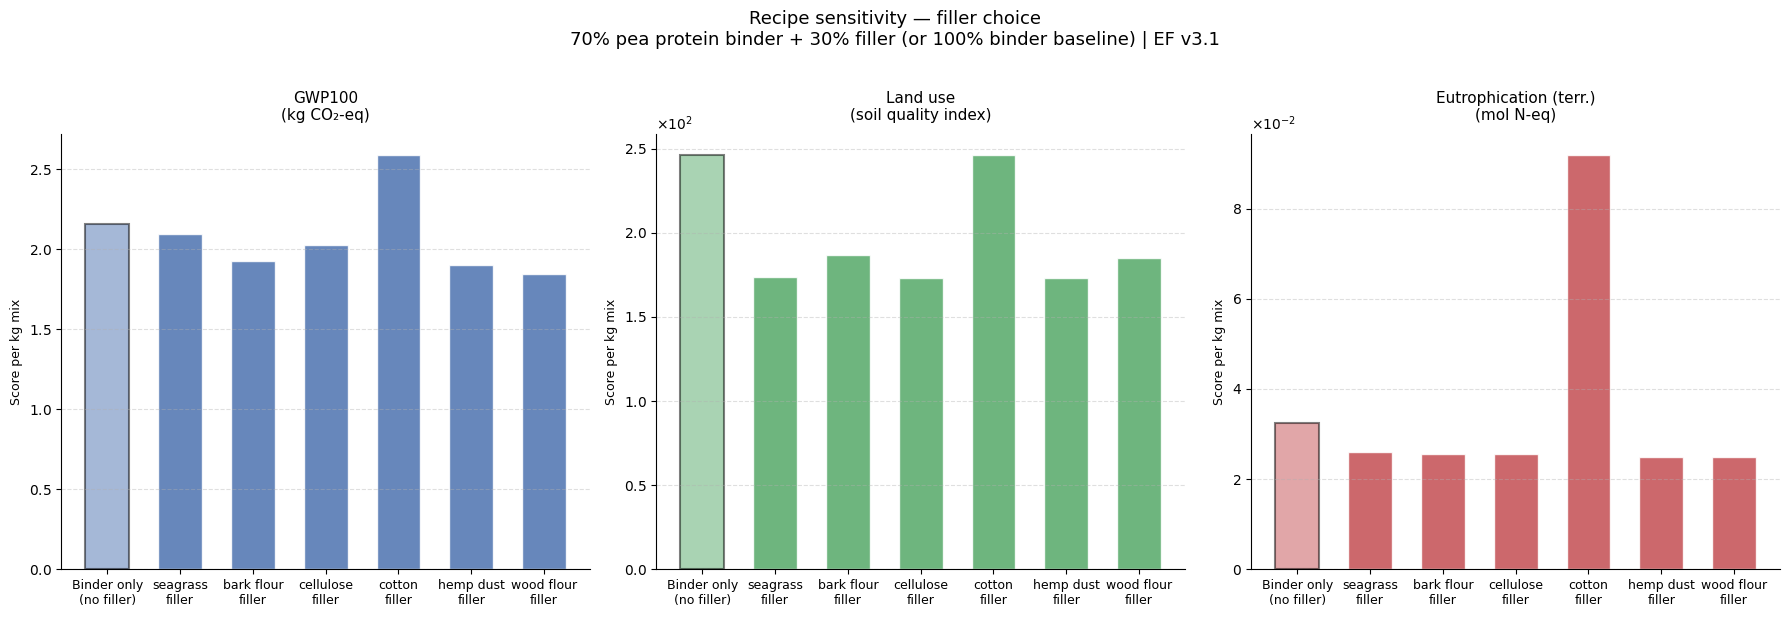

Figure saved.


In [35]:
# ── Recipe sensitivity — filler choice ───────────────────────────────────────
# Seven scenarios: binder-only + one per filler at 30% fraction.
# Each scenario modifies mix preparation, runs LCA, then restores.

BINDER_FRACTION_D = 0.70
FILLER_FRACTION_D = 0.30

SCENARIOS = {"Binder only\n(no filler)": None}
for name in FILLER_NAMES:
    label = name.replace(" filler production", "\nfiller").replace(" production", "")
    SCENARIOS[label] = name

scenario_scores = {label: {} for label in FOCAL_METHODS}

for scenario_label, filler_name in SCENARIOS.items():
    # Apply scenario recipe
    for exc in mix_act.exchanges():
        if exc["type"] != "technosphere":
            continue
        input_name = exc.input["name"]
        if input_name == "pea protein binder production":
            exc["amount"] = 1.0 if filler_name is None else BINDER_FRACTION_D
            exc.save()
        elif input_name in FILLER_NAMES:
            exc["amount"] = FILLER_FRACTION_D if input_name == filler_name else 0.0
            exc.save()

    # Run LCA for each focal method
    for method_label, method in FOCAL_METHODS.items():
        lca = bc.LCA({ref: 1}, method)
        lca.lci()
        lca.lcia()
        scenario_scores[method_label][scenario_label] = lca.score

print(f"Scenario '{scenario_label}' done.")

# Restore Recipe 1
for exc in mix_act.exchanges():
    if exc["type"] == "technosphere" and exc.input["name"] in originals_eq:
        exc["amount"] = originals_eq[exc.input["name"]]
        exc.save()

print("All scenarios complete. Database restored to Recipe 1.")

# ── Plot — grouped bar chart ──────────────────────────────────────────────────
df_scenarios = pd.DataFrame(scenario_scores)
scenario_labels = list(SCENARIOS.keys())
x = np.arange(len(scenario_labels))
n_methods = len(FOCAL_METHODS)
bar_width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

METHOD_COLORS = ["#4C72B0", "#55A868", "#C44E52"]

for ax, (method_label, color) in zip(axes, zip(FOCAL_METHODS, METHOD_COLORS)):
    scores = [df_scenarios.loc[s, method_label] for s in scenario_labels]

    bars = ax.bar(
        x,
        scores,
        color=color,
        edgecolor="white",
        width=0.6,
        alpha=0.85,
    )

    # Highlight binder-only baseline with a different style
    bars[0].set_edgecolor("black")
    bars[0].set_linewidth(1.5)
    bars[0].set_alpha(0.5)

    unit = {
        "GWP100":                 "kg CO₂-eq",
        "Land use":               "soil quality index",
        "Eutrophication (terr.)": "mol N-eq",
    }[method_label]

    ax.set_xticks(x)
    ax.set_xticklabels(scenario_labels, fontsize=9, ha="center")
    ax.set_title(f"{method_label}\n({unit})", fontsize=11, pad=10)
    ax.set_ylabel("Score per kg mix", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle(
    "Recipe sensitivity — filler choice\n"
    "70% pea protein binder + 30% filler (or 100% binder baseline) | EF v3.1",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig("../results/figures/S5_recipe_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")